In [228]:
!pip install pyspark

Step 1: Import & Load Data

In [229]:
from pyspark.sql import SparkSession

In [230]:
spark = SparkSession.builder.appName("SuperstoreAnalysis").getOrCreate()

In [231]:
df = spark.read.csv("/content/Sample - Superstore.csv", header=True, inferSchema=True)


In [232]:
df.show(5)

+------+--------------+----------+----------+--------------+-----------+---------------+---------+-------------+---------------+----------+-----------+------+---------------+---------------+------------+--------------------+--------+--------+--------+--------+
|Row ID|      Order ID|Order Date| Ship Date|     Ship Mode|Customer ID|  Customer Name|  Segment|      Country|           City|     State|Postal Code|Region|     Product ID|       Category|Sub-Category|        Product Name|   Sales|Quantity|Discount|  Profit|
+------+--------------+----------+----------+--------------+-----------+---------------+---------+-------------+---------------+----------+-----------+------+---------------+---------------+------------+--------------------+--------+--------+--------+--------+
|     1|CA-2016-152156| 11/8/2016|11/11/2016|  Second Class|   CG-12520|    Claire Gute| Consumer|United States|      Henderson|  Kentucky|      42420| South|FUR-BO-10001798|      Furniture|   Bookcases|Bush Somerset 

In [233]:
df.printSchema()

root
 |-- Row ID: integer (nullable = true)
 |-- Order ID: string (nullable = true)
 |-- Order Date: string (nullable = true)
 |-- Ship Date: string (nullable = true)
 |-- Ship Mode: string (nullable = true)
 |-- Customer ID: string (nullable = true)
 |-- Customer Name: string (nullable = true)
 |-- Segment: string (nullable = true)
 |-- Country: string (nullable = true)
 |-- City: string (nullable = true)
 |-- State: string (nullable = true)
 |-- Postal Code: integer (nullable = true)
 |-- Region: string (nullable = true)
 |-- Product ID: string (nullable = true)
 |-- Category: string (nullable = true)
 |-- Sub-Category: string (nullable = true)
 |-- Product Name: string (nullable = true)
 |-- Sales: string (nullable = true)
 |-- Quantity: string (nullable = true)
 |-- Discount: string (nullable = true)
 |-- Profit: double (nullable = true)



Step 2: Data Cleaning

In [234]:
df_clean = df.dropDuplicates()

In [235]:
from pyspark.sql.functions import col, when, trim

df_clean = df.withColumn(
    "Sales",
    when(trim(col("Sales")) == "", None)
    .when(trim(col("Sales")).rlike("^[0-9.]+$"), col("Sales"))
    .otherwise(None)
    .cast("double")
).withColumn(
    "Quantity",
    when(trim(col("Quantity")) == "", None)
    .when(trim(col("Quantity")).rlike("^[0-9]+$"), col("Quantity"))
    .otherwise(None)
    .cast("int")
)

In [236]:
df_clean = df_clean.dropna()

In [271]:
df.show(5)

+------+--------------+----------+----------+--------------+-----------+---------------+---------+-------------+---------------+----------+-----------+------+---------------+---------------+------------+--------------------+--------+--------+--------+--------+
|Row ID|      Order ID|Order Date| Ship Date|     Ship Mode|Customer ID|  Customer Name|  Segment|      Country|           City|     State|Postal Code|Region|     Product ID|       Category|Sub-Category|        Product Name|   Sales|Quantity|Discount|  Profit|
+------+--------------+----------+----------+--------------+-----------+---------------+---------+-------------+---------------+----------+-----------+------+---------------+---------------+------------+--------------------+--------+--------+--------+--------+
|     1|CA-2016-152156| 11/8/2016|11/11/2016|  Second Class|   CG-12520|    Claire Gute| Consumer|United States|      Henderson|  Kentucky|      42420| South|FUR-BO-10001798|      Furniture|   Bookcases|Bush Somerset 

In [272]:
df_clean = df_clean.na.fill({
    "Sales": 0,
    "Profit": 0
})

In [273]:
df.show(5)

+------+--------------+----------+----------+--------------+-----------+---------------+---------+-------------+---------------+----------+-----------+------+---------------+---------------+------------+--------------------+--------+--------+--------+--------+
|Row ID|      Order ID|Order Date| Ship Date|     Ship Mode|Customer ID|  Customer Name|  Segment|      Country|           City|     State|Postal Code|Region|     Product ID|       Category|Sub-Category|        Product Name|   Sales|Quantity|Discount|  Profit|
+------+--------------+----------+----------+--------------+-----------+---------------+---------+-------------+---------------+----------+-----------+------+---------------+---------------+------------+--------------------+--------+--------+--------+--------+
|     1|CA-2016-152156| 11/8/2016|11/11/2016|  Second Class|   CG-12520|    Claire Gute| Consumer|United States|      Henderson|  Kentucky|      42420| South|FUR-BO-10001798|      Furniture|   Bookcases|Bush Somerset 

In [262]:
df_clean = df_clean.na.drop(subset=["Customer ID", "Order ID"])

In [260]:
df_clean.show(5)

+------+--------------+----------+----------+--------------+-----------+---------------+---------+-------------+---------------+----------+-----------+------+---------------+---------------+------------+--------------------+--------+--------+--------+--------+
|Row ID|      Order ID|Order Date| Ship Date|     Ship Mode|Customer ID|  Customer Name|  Segment|      Country|           City|     State|Postal Code|Region|     Product ID|       Category|Sub-Category|        Product Name|   Sales|Quantity|Discount|  Profit|
+------+--------------+----------+----------+--------------+-----------+---------------+---------+-------------+---------------+----------+-----------+------+---------------+---------------+------------+--------------------+--------+--------+--------+--------+
|     1|CA-2016-152156| 11/8/2016|11/11/2016|  Second Class|   CG-12520|    Claire Gute| Consumer|United States|      Henderson|  Kentucky|      42420| South|FUR-BO-10001798|      Furniture|   Bookcases|Bush Somerset 

In [263]:
df_clean = df_clean.dropDuplicates(["Customer ID", "Order Date"])


In [264]:
df_clean.show(5)

+------+--------------+----------+---------+--------------+-----------+-------------+--------+-------------+-------------+----------+-----------+-------+---------------+---------------+------------+--------------------+--------+--------+--------+---------+
|Row ID|      Order ID|Order Date|Ship Date|     Ship Mode|Customer ID|Customer Name| Segment|      Country|         City|     State|Postal Code| Region|     Product ID|       Category|Sub-Category|        Product Name|   Sales|Quantity|Discount|   Profit|
+------+--------------+----------+---------+--------------+-----------+-------------+--------+-------------+-------------+----------+-----------+-------+---------------+---------------+------------+--------------------+--------+--------+--------+---------+
|  1300|CA-2015-121391| 10/4/2015|10/7/2015|   First Class|   AA-10315|   Alex Avila|Consumer|United States|San Francisco|California|      94109|   West|OFF-ST-10001590|Office Supplies|     Storage|Tenex Personal Pr...|   26.96| 

In [275]:
df_clean = df_clean.na.fill({
    "Segment": "Unknown"
})

df_clean.show(5)

+------+--------------+----------+---------+--------------+-----------+-------------+--------+-------------+-------------+----------+-----------+-------+---------------+---------------+------------+--------------------+--------+--------+--------+---------+
|Row ID|      Order ID|Order Date|Ship Date|     Ship Mode|Customer ID|Customer Name| Segment|      Country|         City|     State|Postal Code| Region|     Product ID|       Category|Sub-Category|        Product Name|   Sales|Quantity|Discount|   Profit|
+------+--------------+----------+---------+--------------+-----------+-------------+--------+-------------+-------------+----------+-----------+-------+---------------+---------------+------------+--------------------+--------+--------+--------+---------+
|  1300|CA-2015-121391| 10/4/2015|10/7/2015|   First Class|   AA-10315|   Alex Avila|Consumer|United States|San Francisco|California|      94109|   West|OFF-ST-10001590|Office Supplies|     Storage|Tenex Personal Pr...|   26.96| 

In [240]:
df_clean.printSchema()

root
 |-- Row ID: integer (nullable = true)
 |-- Order ID: string (nullable = true)
 |-- Order Date: string (nullable = true)
 |-- Ship Date: string (nullable = true)
 |-- Ship Mode: string (nullable = true)
 |-- Customer ID: string (nullable = true)
 |-- Customer Name: string (nullable = true)
 |-- Segment: string (nullable = true)
 |-- Country: string (nullable = true)
 |-- City: string (nullable = true)
 |-- State: string (nullable = true)
 |-- Postal Code: integer (nullable = true)
 |-- Region: string (nullable = true)
 |-- Product ID: string (nullable = true)
 |-- Category: string (nullable = true)
 |-- Sub-Category: string (nullable = true)
 |-- Product Name: string (nullable = true)
 |-- Sales: double (nullable = false)
 |-- Quantity: integer (nullable = true)
 |-- Discount: string (nullable = true)
 |-- Profit: double (nullable = false)



In [281]:
from pyspark.sql.functions import col

df.filter(col("Segment") == "Consumer").show()

+------+--------------+----------+----------+--------------+-----------+------------------+--------+-------------+---------------+--------------+-----------+-------+---------------+---------------+------------+--------------------+--------+--------+--------+--------+
|Row ID|      Order ID|Order Date| Ship Date|     Ship Mode|Customer ID|     Customer Name| Segment|      Country|           City|         State|Postal Code| Region|     Product ID|       Category|Sub-Category|        Product Name|   Sales|Quantity|Discount|  Profit|
+------+--------------+----------+----------+--------------+-----------+------------------+--------+-------------+---------------+--------------+-----------+-------+---------------+---------------+------------+--------------------+--------+--------+--------+--------+
|     1|CA-2016-152156| 11/8/2016|11/11/2016|  Second Class|   CG-12520|       Claire Gute|Consumer|United States|      Henderson|      Kentucky|      42420|  South|FUR-BO-10001798|      Furniture

Step 3: Filtering & Aggregation

3.1 Filter Region = West

In [241]:
df_west = df_clean.filter(df_clean["Region"] == "West")
df_west.show()

+------+--------------+----------+----------+--------------+-----------+------------------+---------+-------------+-------------+----------+-----------+------+---------------+---------------+------------+--------------------+--------+--------+--------+--------+
|Row ID|      Order ID|Order Date| Ship Date|     Ship Mode|Customer ID|     Customer Name|  Segment|      Country|         City|     State|Postal Code|Region|     Product ID|       Category|Sub-Category|        Product Name|   Sales|Quantity|Discount|  Profit|
+------+--------------+----------+----------+--------------+-----------+------------------+---------+-------------+-------------+----------+-----------+------+---------------+---------------+------------+--------------------+--------+--------+--------+--------+
|     3|CA-2016-138688| 6/12/2016| 6/16/2016|  Second Class|   DV-13045|   Darrin Van Huff|Corporate|United States|  Los Angeles|California|      90036|  West|OFF-LA-10000240|Office Supplies|      Labels|Self-Adhes

3.2 Count records per City > 100

In [242]:
df_west.groupBy("City") \
       .count() \
       .filter("count > 100") \
       .show()

+-------------+-----+
|         City|count|
+-------------+-----+
|  Los Angeles|  731|
|San Francisco|  494|
|    San Diego|  166|
|      Seattle|  412|
+-------------+-----+



3.3 Filter + Aggregation

In [243]:
df_west.groupBy("Category") \
       .sum("Sales") \
       .show()

+---------------+------------------+
|       Category|        sum(Sales)|
+---------------+------------------+
|Office Supplies|213125.18300000002|
|      Furniture|248450.23350000026|
|     Technology|251895.92799999993|
+---------------+------------------+



Step 3.4 – Multiple Aggregations

In [244]:
from pyspark.sql.functions import sum, avg, max, min

df_west.groupBy("Category") \
       .agg(
           sum("Sales").alias("Total_Sales"),
           avg("Sales").alias("Avg_Sales"),
           max("Sales").alias("Max_Sales"),
           min("Sales").alias("Min_Sales")
       ) \
       .show()

+---------------+------------------+------------------+---------+---------+
|       Category|       Total_Sales|         Avg_Sales|Max_Sales|Min_Sales|
+---------------+------------------+------------------+---------+---------+
|Office Supplies|213125.18300000002|117.48907552370453|  8187.65|     1.08|
|      Furniture|248450.23350000026|360.59540420899896| 3610.848|     3.48|
|     Technology|251895.92799999993|422.64417449664415| 13999.96|     0.99|
+---------------+------------------+------------------+---------+---------+



In [270]:
from pyspark.sql.functions import col, avg

df_clean.filter(col("Region") == "West") \
    .groupBy("Category") \
    .agg(avg("Sales").alias("Average_Sales")) \
    .show()

+---------------+------------------+
|       Category|     Average_Sales|
+---------------+------------------+
|Office Supplies|102.71960021786482|
|      Furniture|344.26522927461116|
|     Technology|389.98297769516756|
+---------------+------------------+



STEP 4: Sorting & Ordering

Step 4.1 – Sort by Sales (Descending)

In [245]:
df_clean.orderBy(df_clean["Sales"].desc()).show()

+------+--------------+----------+----------+--------------+-----------+--------------------+-----------+-------------+-------------+--------------+-----------+-------+---------------+---------------+------------+--------------------+---------+--------+--------+----------+
|Row ID|      Order ID|Order Date| Ship Date|     Ship Mode|Customer ID|       Customer Name|    Segment|      Country|         City|         State|Postal Code| Region|     Product ID|       Category|Sub-Category|        Product Name|    Sales|Quantity|Discount|    Profit|
+------+--------------+----------+----------+--------------+-----------+--------------------+-----------+-------------+-------------+--------------+-----------+-------+---------------+---------------+------------+--------------------+---------+--------+--------+----------+
|  2698|CA-2014-145317| 3/18/2014| 3/23/2014|Standard Class|   SM-20320|         Sean Miller|Home Office|United States| Jacksonville|       Florida|      32216|  South|TEC-MA-100

Step 4.2 – Top 10 Highest Sales

In [246]:
df_clean.orderBy(df_clean["Sales"].desc()).limit(10).show()

+------+--------------+----------+----------+--------------+-----------+------------------+-----------+-------------+-------------+------------+-----------+-------+---------------+---------------+------------+--------------------+---------+--------+--------+----------+
|Row ID|      Order ID|Order Date| Ship Date|     Ship Mode|Customer ID|     Customer Name|    Segment|      Country|         City|       State|Postal Code| Region|     Product ID|       Category|Sub-Category|        Product Name|    Sales|Quantity|Discount|    Profit|
+------+--------------+----------+----------+--------------+-----------+------------------+-----------+-------------+-------------+------------+-----------+-------+---------------+---------------+------------+--------------------+---------+--------+--------+----------+
|  2698|CA-2014-145317| 3/18/2014| 3/23/2014|Standard Class|   SM-20320|       Sean Miller|Home Office|United States| Jacksonville|     Florida|      32216|  South|TEC-MA-10002412|     Techn

Step 4.3 – Sort by Category + Sales

In [247]:
df_clean.orderBy(["Category", "Sales"], ascending=[True, False]).show()

+------+--------------+----------+----------+--------------+-----------+-------------------+-----------+-------------+-------------+--------------+-----------+-------+---------------+---------+------------+--------------------+--------+--------+--------+----------+
|Row ID|      Order ID|Order Date| Ship Date|     Ship Mode|Customer ID|      Customer Name|    Segment|      Country|         City|         State|Postal Code| Region|     Product ID| Category|Sub-Category|        Product Name|   Sales|Quantity|Discount|    Profit|
+------+--------------+----------+----------+--------------+-----------+-------------------+-----------+-------------+-------------+--------------+-----------+-------+---------------+---------+------------+--------------------+--------+--------+--------+----------+
|  7244|CA-2017-118892| 8/17/2017| 8/22/2017|  Second Class|   TP-21415|       Tom Prescott|   Consumer|United States| Philadelphia|  Pennsylvania|      19134|   East|FUR-CH-10002024|Furniture|      Cha

Step 4.4 – Top Categories by Total Sales

In [248]:
df_clean.groupBy("Category") \
       .sum("Sales") \
       .orderBy("sum(Sales)", ascending=False) \
       .show()

+---------------+-----------------+
|       Category|       sum(Sales)|
+---------------+-----------------+
|     Technology|835900.0669999964|
|      Furniture|733046.8612999996|
|Office Supplies|703502.9280000031|
+---------------+-----------------+



Step 4.5 Bottom Customers

In [249]:
df_clean.groupBy("Customer Name") \
       .sum("Sales") \
       .orderBy("sum(Sales)", ascending=True) \
       .show(10)

+---------------+----------+
|  Customer Name|sum(Sales)|
+---------------+----------+
|  Thais Sissman|     4.833|
|   Lela Donovan|     5.304|
|Mitch Gastineau|     12.32|
|   Carl Jackson|     16.52|
|     Roy Skaria|    22.328|
| Susan Gilcrest|    41.072|
|Ricardo Emerson|     48.36|
|   Larry Blacks|    50.188|
|   Adrian Shami|     58.82|
|  Barry Weirich|    60.772|
+---------------+----------+
only showing top 10 rows


Step 4.6 Top Cities

In [250]:
df_clean.groupBy("City") \
       .sum("Sales") \
       .orderBy("sum(Sales)", ascending=False) \
       .show(10)

+-------------+------------------+
|         City|        sum(Sales)|
+-------------+------------------+
|New York City|        255248.969|
|  Los Angeles|173168.86500000002|
|      Seattle|117772.58399999999|
|San Francisco|110917.03599999993|
| Philadelphia|107486.47000000006|
|      Houston| 64389.43239999995|
|      Chicago| 47767.33100000003|
|    San Diego| 47115.06099999999|
| Jacksonville|44595.399999999994|
|  Springfield|42791.744000000006|
+-------------+------------------+
only showing top 10 rows


Step 5: Data Visualization

In [251]:
import matplotlib.pyplot as plt

5.1 Sales by Region

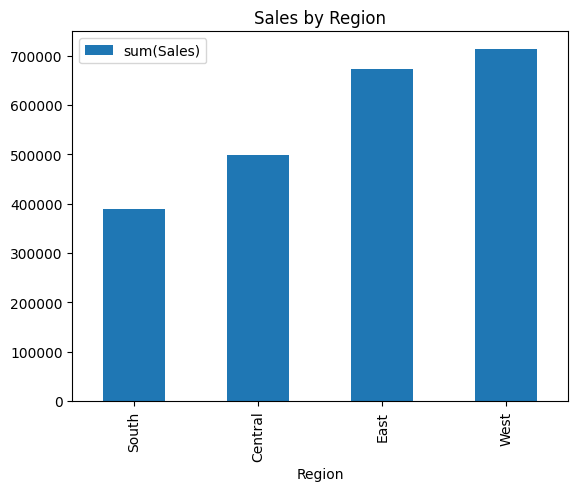

In [252]:
df_clean.groupBy("Region").sum("Sales").toPandas().plot(
    kind='bar', x='Region', y='sum(Sales)', title='Sales by Region'
)
plt.show()

5.2 Sales by Category

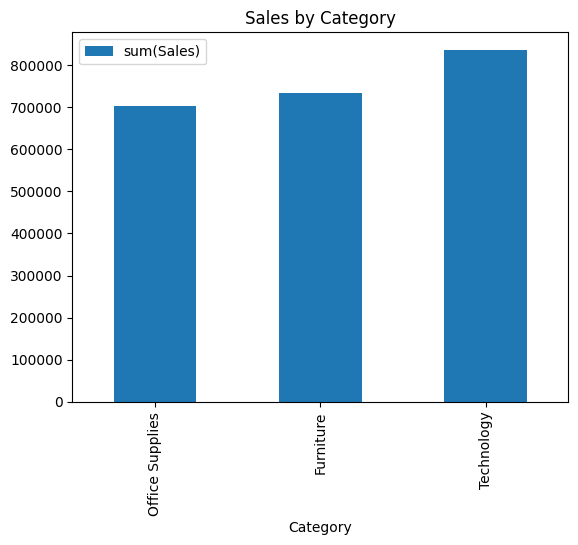

In [253]:
df_clean.groupBy("Category").sum("Sales").toPandas().plot(
    kind='bar', x='Category', y='sum(Sales)', title='Sales by Category'
)
plt.show()

5.3 Top Cities by Sales

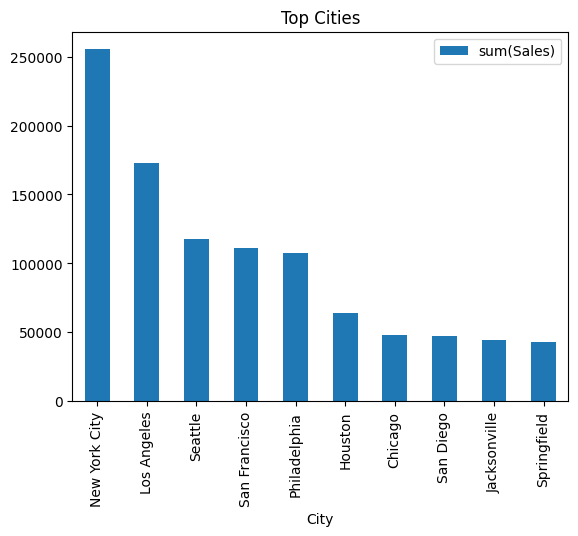

In [254]:
df_clean.groupBy("City").sum("Sales") \
    .toPandas() \
    .sort_values(by="sum(Sales)", ascending=False) \
    .head(10) \
    .plot(kind='bar', x='City', y='sum(Sales)', title='Top Cities')

plt.show()

Insights


- West region has highest sales
- Technology category contributes most revenue
- Few cities dominate total sales
- Customer purchasing is uneven

STEP 6: Data Writing

Step 6.1 – Save Clean Data

In [255]:
df_clean.write.mode("overwrite").csv("output/clean_data")

Step 6.2 – Save as Parquet

In [256]:
df_clean.write.mode("overwrite").parquet("output/clean_data_parquet")

Step 6.3 – Save Aggregated Data

In [257]:
df_west.groupBy("Category") \
       .sum("Sales") \
       .write.mode("overwrite") \
       .csv("output/west_sales_summary")

EXTRA QUESTIONS

In [285]:
from pyspark.sql.functions import to_timestamp, col

df = df.withColumn(
    "event_time",
    to_timestamp(col("Order Date"), "M/d/yyyy")
)

df.show(5)

+------+--------------+----------+----------+--------------+-----------+---------------+---------+-------------+---------------+----------+-----------+------+---------------+---------------+------------+--------------------+--------+--------+--------+--------+-------------------+
|Row ID|      Order ID|Order Date| Ship Date|     Ship Mode|Customer ID|  Customer Name|  Segment|      Country|           City|     State|Postal Code|Region|     Product ID|       Category|Sub-Category|        Product Name|   Sales|Quantity|Discount|  Profit|         event_time|
+------+--------------+----------+----------+--------------+-----------+---------------+---------+-------------+---------------+----------+-----------+------+---------------+---------------+------------+--------------------+--------+--------+--------+--------+-------------------+
|     1|CA-2016-152156| 11/8/2016|11/11/2016|  Second Class|   CG-12520|    Claire Gute| Consumer|United States|      Henderson|  Kentucky|      42420| South

In [287]:
from pyspark.sql.functions import col

df_clean = df.filter(
    (col("Customer Name").isNotNull()) & (col("Customer Name") != "")
)

df_clean.show(5)

+------+--------------+----------+----------+--------------+-----------+---------------+---------+-------------+---------------+----------+-----------+------+---------------+---------------+------------+--------------------+--------+--------+--------+--------+-------------------+
|Row ID|      Order ID|Order Date| Ship Date|     Ship Mode|Customer ID|  Customer Name|  Segment|      Country|           City|     State|Postal Code|Region|     Product ID|       Category|Sub-Category|        Product Name|   Sales|Quantity|Discount|  Profit|         event_time|
+------+--------------+----------+----------+--------------+-----------+---------------+---------+-------------+---------------+----------+-----------+------+---------------+---------------+------------+--------------------+--------+--------+--------+--------+-------------------+
|     1|CA-2016-152156| 11/8/2016|11/11/2016|  Second Class|   CG-12520|    Claire Gute| Consumer|United States|      Henderson|  Kentucky|      42420| South